In [1]:
root_dir = "/home/velocitatem/Documents/University/Third Year/Statistical Learning/final_project/"
import sys
sys.path.append(root_dir)
from classification.data.loader import get_full_dataset
from classification.data.minio_handler import MinioManager
from classification.data.augmentor import Augmentor

/home/velocitatem/Documents/University/Third Year/Statistical Learning/final_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-06 18:20:37,681 - INFO - Logger initialized: cache_loader
2025-04-06 18:20:37,682 - INFO - Log directory: logs/cache_loader
2025-04-06 18:20:37,690 - INFO - Logger initialized: kaggle_invoices_loader
2025-04-06 18:20:37,690 - INFO - Log directory: logs/kaggle_invoices_loader
2025-04-06 18:20:37,691 - INFO - Logger initialized: hf_invoices_loader
2025-04-06 18:20:37,691 - INFO - Log directory: logs/hf_invoices_loader


In [2]:
datasets_list = ["rvl_cdip", "kaggle_invoices", "hf_invoices"]
minio_manager = MinioManager()
augmentor = Augmentor()
apply_ocr = True
dataset = get_full_dataset(datasets_list, minio_manager, augmentor, apply_ocr)

2025-04-06 18:20:39,070 - data_loader - INFO - Loading datasets in parallel: ['rvl_cdip', 'kaggle_invoices', 'hf_invoices']
2025-04-06 18:20:39,071 - data_loader - INFO - Loading dataset: rvl_cdip with OCR: True
2025-04-06 18:20:39,072 - data_loader - INFO - Loading dataset: kaggle_invoices with OCR: True
2025-04-06 18:20:39,073 - data_loader - INFO - Loading dataset: hf_invoices with OCR: True
2025-04-06 18:20:39,078 - INFO - KaggleInvoicesLoader initialized with seed 42
2025-04-06 18:20:39,078 - INFO - Loading Kaggle Invoices dataset
2025-04-06 18:20:39,079 - INFO - Parameters: chunk_size=100, total_samples=None, apply_augmentation=True, augmentation_factor=3
2025-04-06 18:20:39,079 - INFO - HFInvoicesLoader initialized with seed 42
2025-04-06 18:20:39,080 - INFO - Loading HuggingFace Invoices dataset
2025-04-06 18:20:39,080 - INFO - Parameters: chunk_size=100, total_samples=None, apply_augmentation=True, augmentation_factor=3, split=train
2025-04-06 18:20:39,081 - INFO - Loading cac

!!! True


2025-04-06 18:20:41,738 - INFO - Loading cached dataset from data_cache/rvl_cdip_chunk_size=2000_total_samples=10000_apply_augmentation=True_augmentation_factor=2_apply_ocr=True.pkl
2025-04-06 18:20:42,483 - data_loader - INFO - Combined dataset created with 11255 samples
2025-04-06 18:20:42,488 - data_loader - INFO - Combined dataset created with 8553 samples


In [3]:
dataset.head()

,image,label,source_dataset,is_augmented,global_id,ocr_text,ocr_confidence,ocr_boxes
0,http://localhost:9900/dapper/src_rvl_cdip_cls_...,promotional,rvl_cdip,False,rvl_cdip_0,a7 9L %R0 BRI DRI 613 1 3 draft #4 statement f...,86.803797,"[{'text': 'a7', 'conf': 10, 'left': 56, 'top':..."
1,http://localhost:9900/dapper/src_rvl_cdip_cls_...,invoice,rvl_cdip,False,rvl_cdip_1,"'WALSTON, STABLER, WELLS, ANDERSON & Bas 500 F...",73.751269,"[{'text': ''WALSTON,', 'conf': 39, 'left': 194..."
2,http://localhost:9900/dapper/src_rvl_cdip_cls_...,correspondence,rvl_cdip,False,rvl_cdip_2,"P anning,icheoP. Viednostay, Augus 01,2001 £09...",50.333333,"[{'text': 'P', 'conf': 43, 'left': 105, 'top':..."
3,http://localhost:9900/dapper/src_rvl_cdip_cls_...,invoice,rvl_cdip,False,rvl_cdip_3,BRITISH-AMERICAN TOBACCO COMPANY LTD Brown & W...,65.045455,"[{'text': 'BRITISH-AMERICAN', 'conf': 92, 'lef..."
4,http://localhost:9900/dapper/src_rvl_cdip_cls_...,forms,rvl_cdip,False,rvl_cdip_4,LAB SERVICES CONSISTENCY REPORT DATE: £ TECHNI...,60.077381,"[{'text': 'LAB', 'conf': 92, 'left': 89, 'top'..."


In [4]:
dataset['label'].value_counts()

label
invoice           1806
other             1292
forms             1278
correspondence    1261
scientific        1005
personal           965
promotional        946
Name: count, dtype: int64

<Axes: xlabel='label'>

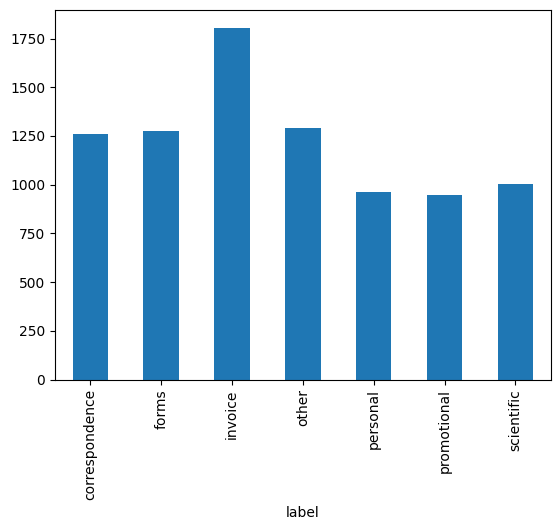

In [5]:
dataset.groupby('label').size().plot(kind='bar')

In [6]:
dataset.isna().sum()

image                0
label                0
source_dataset       0
is_augmented         0
global_id            0
ocr_text          1255
ocr_confidence    1255
ocr_boxes         1255
dtype: int64

In [12]:
# proprtion of invoices where we have the word "invoice" in the text
# regex match invoice but possibly with other words or errors
import re

# Create a regex pattern to match "invoice" with possible variations
invoice_pattern = r'\binvoice\b|invoice'
dataset[dataset['label'] == 'invoice']['ocr_text'].apply(lambda x: re.search(invoice_pattern, str(x).lower())).notna().mean()

np.float64(0.08084163898117387)

In [13]:
# lets look at the images where we have the word "invoice" in the text
dataset[dataset['label'] == 'invoice']['image'].head()
# see the urls after the dapper string
dataset[dataset['label'] == 'invoice']['image'].apply(lambda x: x.split('dapper/')[1]).head()

1      src_rvl_cdip_cls_invoice_idx_1_orig.jpg
3      src_rvl_cdip_cls_invoice_idx_3_orig.jpg
30    src_rvl_cdip_cls_invoice_idx_30_orig.jpg
65    src_rvl_cdip_cls_invoice_idx_65_orig.jpg
72    src_rvl_cdip_cls_invoice_idx_72_orig.jpg
Name: image, dtype: object

In [15]:
from classification.training.models import CNNClassifier

In [32]:
!pip install torchviz torchinfo -q

## CNN View

In [33]:
from torchviz import make_dot
import torch

# Create a dummy input tensor
# Create a dummy model
model = CNNClassifier(
    input_channels=3,
    learning_rate=0.001,
    num_classes=len(dataset['label'].unique())
)
dummy_input = torch.randn(1, 3, 224, 224).to(model.device)

# Create a dummy output tensor
dummy_output = model.model(dummy_input)

# Create a dot graph
dot = make_dot(dummy_output, params=dict(model.model.named_parameters()), show_attrs=True, show_saved=True)
dot.graph_attr.update(rankdir='LR')  # Left-to-right layout
dot.render('model_graph', format='png')

# save to model_images
import os
os.makedirs('model_images', exist_ok=True)
dot.render('cnn', format='png', directory='model_images')


'model_images/cnn.png'

In [35]:
import torchinfo
torchinfo.summary(model.model, (1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
CNNModel                                 [1, 7]                    --
├─Conv2d: 1-1                            [1, 32, 224, 224]         896
├─MaxPool2d: 1-2                         [1, 32, 112, 112]         --
├─Conv2d: 1-3                            [1, 64, 112, 112]         18,496
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Conv2d: 1-5                            [1, 128, 56, 56]          73,856
├─MaxPool2d: 1-6                         [1, 128, 28, 28]          --
├─Linear: 1-7                            [1, 512]                  51,380,736
├─Dropout: 1-8                           [1, 512]                  --
├─Linear: 1-9                            [1, 7]                    3,591
Total params: 51,477,575
Trainable params: 51,477,575
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 559.97
Input size (MB): 0.60
Forward/backward pass size (MB): 22.48
Params size (MB): 205.91

## LSNet View

In [36]:
from classification.training.models import LSNetClassifier
"""
class LSNetClassifier(
    num_classes: int | None = None,
    model_size: str = 't',
    learning_rate: float = 0.001,
    weight_decay: float = 0.0001,
    device: str | None = None,
    num_epochs: int = 100,
    batch_size: int = 64,
    num_workers: int = 4,
    pretrained: bool = False,
    freeze_backbone: bool = False,
    config: Dict[str, Any] | None = None
)
"""
model = LSNetClassifier(
    num_classes=len(dataset['label'].unique()),
    model_size='t',
    learning_rate=0.001,
    weight_decay=0.0001,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    num_epochs=100,
    batch_size=64,
)
dummy_input = torch.randn(1, 3, 224, 224).to(model.device)
dot = make_dot(model.model(dummy_input), params=dict(model.model.named_parameters()), show_attrs=True, show_saved=True)
dot.graph_attr.update(rankdir='LR')  # Left-to-right layout
dot.render('model_graph', format='png')

# save to model_images
import os
os.makedirs('model_images', exist_ok=True)
dot.render('lsnet', format='png', directory='model_images')

2025-04-06 18:44:42,771 - lsnet_classifier - INFO - Using device: cuda
2025-04-06 18:44:42,771 - lsnet_classifier - INFO - GPU: NVIDIA GeForce RTX 4080 Laptop GPU
2025-04-06 18:44:42,772 - lsnet_classifier - INFO - CUDA Version: 12.4
2025-04-06 18:44:42,772 - lsnet_classifier - INFO - Available GPU memory: 12.46 GB


'model_images/lsnet.png'

In [37]:
torchinfo.summary(model.model, (1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
LSNet                                    [1, 7]                    --
├─Sequential: 1-1                        [1, 64, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
├─MaxPool2d: 1-2                         [1, 64, 56, 56]           --
├─Sequential: 1-3                        [1, 64, 56, 56]           --
│    └─LSBlock: 2-4                      [1, 64, 56, 56]           --
│    │    └─LSConvolution: 3-1           [1, 64, 56, 56]           237,824
│    │    └─Sequential: 3-2              [1, 64, 56, 56]           --
│    └─LSBlock: 2-5                      [1, 64, 56, 56]           --
│    │    └─LSConvolution: 3-3           [1, 64, 56, 56]           237,824
│    │    └─Sequential: 3-4              [1, 64, 56, 56]           --
├

## EAML View

In [46]:
from classification.training.eaml import EAMLClassifier
"""
    ##
    # @brief Constructor for EAMLClassifier class
    # @param num_classes Number of document classes
    # @param vocab_size Size of the vocabulary for text embedding
    # @param embedding_dim Dimension of the word embeddings
    # @param word_hidden_dim Dimension of the word-level GRU hidden state
    # @param sent_hidden_dim Dimension of the sentence-level GRU hidden state
    # @param image_channels Number of input image channels
    # @param image_feature_dim Dimension of the image feature vector
    # @param image_size Tuple of (height, width) for image resizing
    # @param dropout Dropout rate for regularization
    # @param learning_rate Learning rate for the optimizer
    # @param device Device to use for training ('cuda' or 'cpu')
    # @param num_epochs Number of training epochs
    # @param use_ocr_text Whether to use OCR text from the dataset
    #
"""
model = EAMLClassifier(
    num_classes=len(dataset['label'].unique()),
    vocab_size=len(dataset['ocr_text'].unique()),
    embedding_dim=100,
    word_hidden_dim=50,
    sent_hidden_dim=50,
    image_channels=3,
    image_feature_dim=128,
    image_size=(224, 224),
    dropout=0.5,
    learning_rate=0.0005,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    num_epochs=50,
    use_ocr_text=True
)

# Create dummy inputs for both image and text
dummy_image = torch.randn(1, 3, 224, 224).to(model.device)
dummy_text = torch.randint(0, model.vocab_size, (1, 15, 50)).to(model.device)  # (batch_size, max_sentences, max_sent_length)

dummy_output = model.model(docs=dummy_text, images=dummy_image)

dot = make_dot(dummy_output, params=dict(model.model.named_parameters()), show_attrs=True, show_saved=True)
dot.graph_attr.update(rankdir='LR')  # Left-to-right layout
dot.render('eaml', format='png', directory='model_images')

# Print model summary
torchinfo.summary(model.model, input_data=[dummy_text, dummy_image])


Layer (type:depth-idx)                   Output Shape              Param #
EAML                                     [1, 7]                    --
├─Embedding: 1-1                         [15, 50, 100]             704,200
├─Dropout: 1-2                           [15, 50, 100]             --
├─GRU: 1-3                               [15, 50, 100]             45,600
├─WordAttention: 1-4                     [15, 100]                 --
│    └─Linear: 2-1                       [15, 50, 100]             10,100
│    └─Linear: 2-2                       [15, 50, 1]               100
├─Dropout: 1-5                           [15, 100]                 --
├─GRU: 1-6                               [1, 15, 100]              45,600
├─SentenceAttention: 1-7                 [1, 100]                  --
│    └─Linear: 2-3                       [1, 15, 100]              10,100
│    └─Linear: 2-4                       [1, 15, 1]                100
├─ImageEncoder: 1-8                      [1, 128]             

## Hybrid View

In [41]:
from classification.training.hybrid import HybridClassifier
"""
class HybridClassifier(
    num_classes: int,
    vocab_size: int,
    embedding_dim: int = 100,
    word_hidden_dim: int = 50,
    sent_hidden_dim: int = 50,
    lsnet_model_size: str = 's',
    dropout: float = 0.5,
    learning_rate: float = 0.0005,
    device: str | None = None,
    num_epochs: int = 50
)
"""
model = HybridClassifier(
    num_classes=len(dataset['label'].unique()),
    vocab_size=len(dataset['ocr_text'].unique()),
    embedding_dim=100,
    word_hidden_dim=50,
    sent_hidden_dim=50,
    lsnet_model_size='s',
    dropout=0.5,
    learning_rate=0.0005,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    num_epochs=50
)

# Create dummy inputs for both image and text
dummy_image = torch.randn(1, 3, 224, 224).to(model.device)
dummy_text = torch.randint(0, model.vocab_size, (1, 15, 50)).to(model.device)  # (batch_size, max_sentences, max_sent_length)

# Forward pass with both inputs
dummy_output = model.model(docs=dummy_text, images=dummy_image)

dot = make_dot(dummy_output, params=dict(model.model.named_parameters()), show_attrs=True, show_saved=True)
dot.graph_attr.update(rankdir='LR')  # Left-to-right layout
dot.render('model_graph', format='png')

# save to model_images
import os
os.makedirs('model_images', exist_ok=True)
dot.render('hybrid', format='png', directory='model_images')

2025-04-06 18:47:51,599 - lsnet_classifier - INFO - Using device: cuda
2025-04-06 18:47:51,600 - lsnet_classifier - INFO - GPU: NVIDIA GeForce RTX 4080 Laptop GPU
2025-04-06 18:47:51,600 - lsnet_classifier - INFO - CUDA Version: 12.4
2025-04-06 18:47:51,601 - lsnet_classifier - INFO - Available GPU memory: 12.46 GB
/home/velocitatem/Documents/University/Third Year/Statistical Learning/final_project/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


'model_images/hybrid.png'

In [45]:
# both image and text
dummy_image = torch.randn(1, 3, 224, 224).to(model.device)
dummy_text = torch.randint(0, model.vocab_size, (1, 15, 50)).to(model.device)  # (batch_size, max_sentences, max_sent_length)

torchinfo.summary(model.model, input_data=(dummy_image, dummy_text))

Layer (type:depth-idx)                        Output Shape              Param #
HybridModel                                   [1, 7]                    --
├─LSNet: 1-1                                  [1, 512]                  --
│    └─Sequential: 2-1                        [1, 64, 112, 112]         --
│    │    └─Conv2d: 3-1                       [1, 64, 112, 112]         9,408
│    │    └─BatchNorm2d: 3-2                  [1, 64, 112, 112]         128
│    │    └─ReLU: 3-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-2                         [1, 64, 56, 56]           --
│    └─Sequential: 2-3                        [1, 64, 56, 56]           --
│    │    └─LSBlock: 3-4                      [1, 64, 56, 56]           237,824
│    │    └─LSBlock: 3-5                      [1, 64, 56, 56]           237,824
│    │    └─LSBlock: 3-6                      [1, 64, 56, 56]           237,824
│    └─Sequential: 2-4                        [1, 128, 28, 28]          --
│

## Resnet View

In [48]:
from classification.training.resnet import ResNetClassifier
# Initialize ResNet model
resnet_model = ResNetClassifier(
    num_classes=len(dataset['label'].unique()),
    trained_model_name='resnet18',
    pretrained=True,
    learning_rate=0.001,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    num_epochs=50
)

# Create dummy input for visualization
dummy_input = torch.randn(1, 3, 224, 224).to(resnet_model.device)

# Forward pass
dummy_output = resnet_model.model(dummy_input)

# Create visualization
dot = make_dot(dummy_output, params=dict(resnet_model.model.named_parameters()), show_attrs=True, show_saved=True)
dot.graph_attr.update(rankdir='LR')  # Left-to-right layout

# Save visualization
os.makedirs('model_images', exist_ok=True)
dot.render('resnet', format='png', directory='model_images')

# Print model summary
torchinfo.summary(resnet_model.model, input_data=dummy_input)

/home/velocitatem/Documents/University/Third Year/Statistical Learning/final_project/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 7]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│